# A2.1 Regresión logística y validación cruzada
## 1. Definición del problema de clasificación
En la etapa anterior del proyecto se trabajó con un problema de regresión enfocado en modelar una variable cuantitativa continua. En esta actividad, el problema se reformula dentro de un escenario de clasificación, utilizando regresión logística como modelo base.

La variable seleccionada como objetivo es Confianza en la policía, originalmente expresada como un porcentaje continuo. Dado que la regresión logística requiere una variable de salida cualitativa, se procedió a construir una variable binaria que distingue entre estados con alta confianza y baja confianza.

Para realizar esta transformación se utilizó la mediana nacional de la variable como punto de corte. De esta forma, se definió:

Clase 1: Estados con confianza en la policía superior a la mediana.

Clase 0: Estados con confianza en la policía menor o igual a la mediana.

La elección de la mediana como umbral presenta varias ventajas metodológicas. En primer lugar, reduce la influencia de posibles valores extremos que podrían sesgar la separación si se utilizara el promedio. En segundo lugar, tiende a generar clases más balanceadas, lo cual es particularmente importante en problemas de clasificación, ya que modelos entrenados con clases altamente desbalanceadas pueden producir estimaciones sesgadas hacia la clase mayoritaria.

Bajo esta formulación, el objetivo del modelo consiste en estimar la probabilidad de que un estado presente alta confianza en la policía, en función de un conjunto de variables económicas y sociales previamente consideradas en el análisis exploratorio. Este planteamiento permite interpretar los resultados en términos probabilísticos y analizar qué factores se asocian positiva o negativamente con la confianza institucional.

In [9]:
import pandas as pd
import numpy as np

# Cargar base
df = pd.read_excel("A2.1 Base de datos Confianza en la policia.xlsx")

# Crear variable binaria
umbral = df["Confianza en la policía"].median()
df["Y_confianza"] = (df["Confianza en la policía"] > umbral).astype(int)

# Conteo absoluto
conteo = df["Y_confianza"].value_counts().sort_index()

# Proporción
proporcion = df["Y_confianza"].value_counts(normalize=True).sort_index()

print("Umbral (mediana):", umbral)
print("\nConteo por clase:")
print(conteo)

print("\nProporción por clase:")
print(proporcion)

Umbral (mediana): 56.3

Conteo por clase:
Y_confianza
0    16
1    16
Name: count, dtype: int64

Proporción por clase:
Y_confianza
0    0.5
1    0.5
Name: proportion, dtype: float64


La mediana de la variable Confianza en la policía fue de 56.3, valor que se utilizó como umbral para la construcción de la variable binaria. Tras aplicar este criterio de separación, el conjunto de datos quedó dividido en 16 estados clasificados como alta confianza (1) y 16 estados clasificados como baja confianza (0).

Esto implica que cada clase representa el 50% del total de observaciones, evidenciando un balance perfecto entre clases. Este resultado es metodológicamente favorable, ya que evita problemas comunes en clasificación asociados al desbalance, donde el modelo tiende a favorecer la clase mayoritaria. En este caso, la distribución equitativa permitirá que el modelo de regresión logística aprenda patrones asociados a ambas clases sin sesgos estructurales derivados de la frecuencia relativa.

En consecuencia, no será necesario aplicar técnicas adicionales de balanceo, como ponderación de clases o sobremuestreo, al menos en esta etapa inicial del análisis.

## 2. Separación de datos y balance de clases
Con el objetivo de evaluar el desempeño del modelo bajo un esquema realista de generalización, el conjunto de datos se dividió en subconjuntos de entrenamiento y prueba utilizando una partición 70/30. Dado que el problema corresponde a una tarea de clasificación binaria, se aplicó una separación estratificada con base en la variable objetivo, con el fin de conservar la proporción de clases en ambos subconjuntos.

El conjunto completo está compuesto por 32 observaciones, distribuidas equitativamente entre las dos clases: 16 estados clasificados como baja confianza (0) y 16 como alta confianza (1), lo que representa una proporción del 50% para cada clase.

Tras la partición estratificada, el conjunto de entrenamiento quedó conformado por 22 observaciones (11 por clase), manteniendo una proporción del 50% para cada categoría. De igual forma, el conjunto de prueba quedó compuesto por 10 observaciones, conservando la misma distribución relativa de clases.

Esta consistencia en la proporción de clases entre el conjunto original, el de entrenamiento y el de prueba es fundamental en problemas de clasificación, ya que evita sesgos en la estimación del desempeño del modelo. Si la distribución de clases variara significativamente entre conjuntos, métricas como precisión, recall o AUC podrían verse afectadas, generando interpretaciones incorrectas sobre la capacidad discriminativa del modelo.

En consecuencia, la separación estratificada aplicada garantiza una evaluación más estable y representativa del desempeño esperado en datos no observados.

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Cargar base
df = pd.read_excel("A2.1 Base de datos Confianza en la policia.xlsx")

# Crear variable objetivo binaria (del apartado 1)
umbral = df["Confianza en la policía"].median()
df["Y_confianza"] = (df["Confianza en la policía"] > umbral).astype(int)

# ================================
# Separar X e y
# ================================
cols_a_eliminar = ["Confianza en la policía", "Y_confianza"]

# Si tienes columna "Estado", también elimínala para que no "memorice"
if "Estado" in df.columns:
    cols_a_eliminar.append("Estado")

X = df.drop(columns=cols_a_eliminar)
y = df["Y_confianza"]

# ================================
# Train/Test estratificado
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ================================
# Verificar balance de clases
# ================================
def resumen_balance(y_vec, nombre):
    conteo = y_vec.value_counts().sort_index()
    prop = y_vec.value_counts(normalize=True).sort_index()
    print(f"\n--- {nombre} ---")
    print("Conteo:\n", conteo)
    print("Proporción:\n", prop)

resumen_balance(y, "Dataset completo")
resumen_balance(y_train, "Entrenamiento")
resumen_balance(y_test, "Prueba")

print("\nTamaños:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


--- Dataset completo ---
Conteo:
 Y_confianza
0    16
1    16
Name: count, dtype: int64
Proporción:
 Y_confianza
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Entrenamiento ---
Conteo:
 Y_confianza
0    11
1    11
Name: count, dtype: int64
Proporción:
 Y_confianza
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Prueba ---
Conteo:
 Y_confianza
0    5
1    5
Name: count, dtype: int64
Proporción:
 Y_confianza
0    0.5
1    0.5
Name: proportion, dtype: float64

Tamaños:
X_train: (22, 11) X_test: (10, 11)
y_train: (22,) y_test: (10,)


## 3. Evaluación mediante validación cruzada

Con el fin de obtener una estimación más robusta del desempeño esperado del modelo, se aplicó validación cruzada estratificada con cinco particiones utilizando exclusivamente el conjunto de entrenamiento.

A diferencia del intento inicial sin escalado, en esta etapa se implementó un Pipeline que incluye la estandarización de las variables explicativas mediante StandardScaler, seguida del modelo de regresión logística con regularización L2. La estandarización resulta particularmente importante cuando las variables presentan escalas muy distintas, ya que la regresión logística es sensible a diferencias de magnitud entre predictores.

Las métricas promedio obtenidas mediante validación cruzada fueron:

Accuracy ≈ 0.45 (± 0.12)
Precision ≈ 0.40 (± 0.20)
Recall ≈ 0.47 (± 0.32)
F1-score ≈ 0.41 (± 0.22)
ROC-AUC ≈ 0.53 (± 0.17)

El valor promedio del AUC ligeramente superior a 0.5 indica que el modelo presenta una capacidad discriminativa marginalmente mejor que el azar. No obstante, la desviación estándar relativamente elevada sugiere una variabilidad considerable entre particiones, lo cual es esperable dado el reducido tamaño del conjunto de entrenamiento (22 observaciones).

El análisis del ROC-AUC por fold evidencia esta inestabilidad: algunos subconjuntos muestran una capacidad discriminativa moderada (valores cercanos a 0.75), mientras que otros presentan desempeños inferiores (cercanos a 0.25). Este comportamiento refleja la sensibilidad del modelo ante pequeñas variaciones en los datos disponibles.

En conjunto, los resultados indican que, si bien el modelo logra capturar cierta señal en los datos, su capacidad predictiva es limitada y altamente dependiente de la partición utilizada. La validación cruzada cumple aquí un papel fundamental, ya que permite identificar esta variabilidad y evitar conclusiones basadas en una sola división entrenamiento–prueba.

accuracy: mean = 0.4500 | std = 0.1183
precision: mean = 0.4000 | std = 0.2000
recall: mean = 0.4667 | std = 0.3232
f1: mean = 0.4133 | std = 0.2237
roc_auc: mean = 0.5333 | std = 0.1716


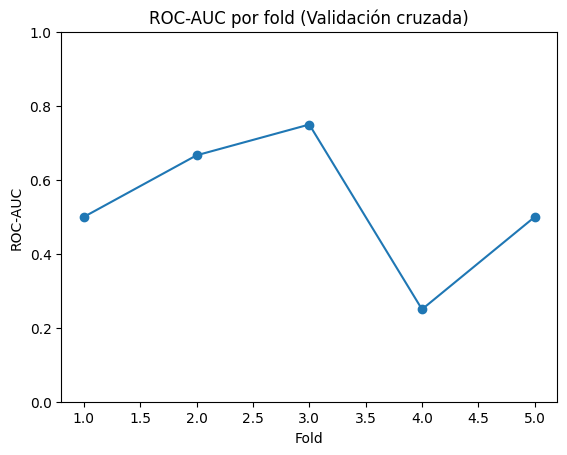

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import matplotlib.pyplot as plt

# Pipeline: Escalado + Logística
pipeline_log = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l2",
        max_iter=2000
    ))
])

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resultados_cv = cross_validate(
    pipeline_log,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    return_train_score=False
)

# Mostrar resultados
for m in metricas:
    media = resultados_cv[f"test_{m}"].mean()
    std = resultados_cv[f"test_{m}"].std()
    print(f"{m}: mean = {media:.4f} | std = {std:.4f}")

# Graficar AUC por fold
auc_scores = resultados_cv["test_roc_auc"]

plt.figure()
plt.plot(range(1,6), auc_scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC por fold (Validación cruzada)")
plt.ylim(0,1)
plt.show()

## 4. Entrenamiento final y evaluación en prueba
Una vez estimado el desempeño esperado mediante validación cruzada, se entrenó el modelo final utilizando la totalidad del conjunto de entrenamiento (22 observaciones) y posteriormente se evaluó su desempeño sobre el conjunto de prueba independiente (10 observaciones).

### Matriz de confusión
La matriz de confusión obtenida en el conjunto de prueba fue:

Verdaderos negativos (TN): 1
Falsos positivos (FP): 4
Falsos negativos (FN): 3
Verdaderos positivos (TP): 2

Estos resultados muestran que el modelo tiende a cometer un número considerable de errores en ambas clases, particularmente falsos positivos.

### Métricas de desempeño en prueba
Las métricas obtenidas fueron:
Accuracy: 0.30
Precision: 0.33
Recall: 0.40
F1-score: 0.36
AUC: 0.32

El valor de accuracy (30%) es inferior al 50% que correspondería a una clasificación aleatoria en un conjunto perfectamente balanceado. Asimismo, el AUC de 0.32 indica que el modelo presenta una capacidad discriminativa baja en el conjunto de prueba.

En comparación con la validación cruzada (AUC ≈ 0.53), se observa una disminución en el desempeño al evaluar en datos no utilizados durante el ajuste. Esta diferencia puede atribuirse principalmente al tamaño reducido del conjunto de datos, lo cual incrementa la variabilidad y hace que el modelo sea altamente sensible a la partición utilizada.

### Análisis bajo distintos umbrales de decisión
Se evaluó el comportamiento del modelo modificando el umbral de clasificación:
Umbral = 0.3
Precision: 0.50
Recall: 0.80
F1: 0.62

Umbral = 0.5
Precision: 0.33
Recall: 0.40
F1: 0.36

Umbral = 0.7
Precision: 0.50
Recall: 0.20
F1: 0.29

El análisis evidencia el clásico trade-off entre precisión y recall:

Con umbral bajo (0.3), el modelo identifica más casos de alta confianza (alto recall), pero incrementa falsos positivos.
Con umbral alto (0.7), el modelo se vuelve más conservador, aumentando precisión pero reduciendo considerablemente la capacidad de detectar positivos.
Este comportamiento confirma que el umbral de decisión tiene un impacto directo sobre las métricas y que la elección óptima depende del objetivo del análisis. Si el interés fuera maximizar la detección de estados con alta confianza, un umbral menor podría resultar más adecuado.

### Curva ROC y AUC
La curva ROC construida a partir de las probabilidades estimadas muestra un desempeño cercano a la línea diagonal, lo que indica una capacidad limitada para discriminar entre estados de alta y baja confianza. El AUC de 0.32 confirma esta baja capacidad discriminativa en el conjunto de prueba.

Un AUC inferior a 0.5 indica que el modelo clasifica peor que una asignación aleatoria, lo cual refuerza la evidencia de inestabilidad bajo el tamaño muestral disponible.

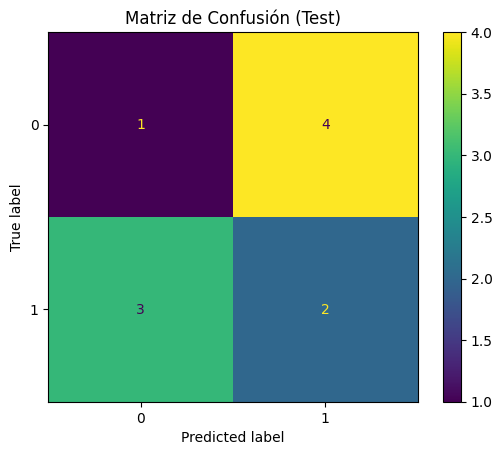

Accuracy: 0.3
Precision: 0.3333333333333333
Recall: 0.4
F1: 0.3636363636363636
AUC: 0.32


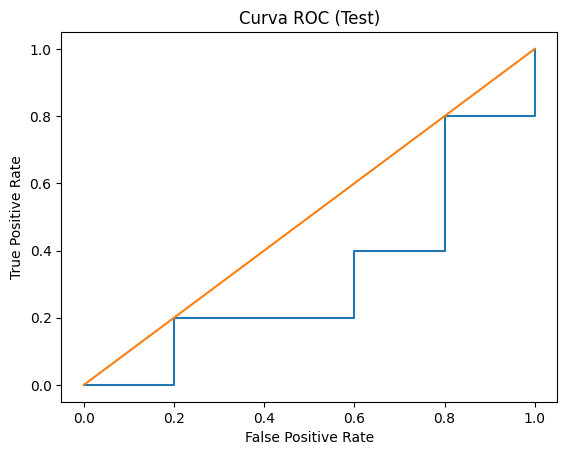

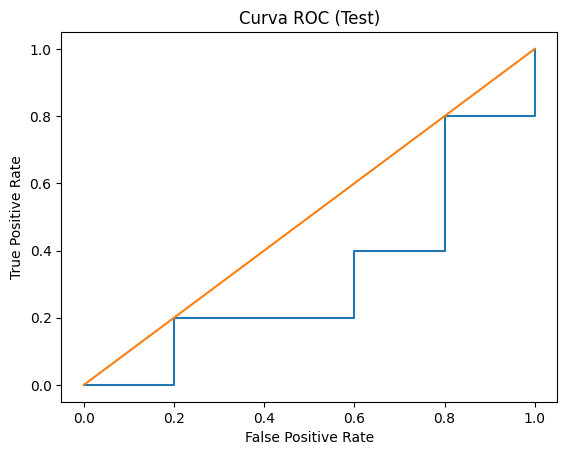


Umbral: 0.3
Precision: 0.5
Recall: 0.8
F1: 0.6153846153846154

Umbral: 0.5
Precision: 0.3333333333333333
Recall: 0.4
F1: 0.3636363636363636

Umbral: 0.7
Precision: 0.5
Recall: 0.2
F1: 0.28571428571428575


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Entrenar modelo final
# =========================
pipeline_log.fit(X_train, y_train)

# =========================
# Predicciones
# =========================
proba_test = pipeline_log.predict_proba(X_test)[:,1]
pred_test = (proba_test >= 0.5).astype(int)

# =========================
# Matriz de confusión
# =========================
cm = confusion_matrix(y_test, pred_test)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Matriz de Confusión (Test)")
plt.show()

# =========================
# Métricas
# =========================
acc = accuracy_score(y_test, pred_test)
prec = precision_score(y_test, pred_test, zero_division=0)
rec = recall_score(y_test, pred_test, zero_division=0)
f1 = f1_score(y_test, pred_test, zero_division=0)
auc = roc_auc_score(y_test, proba_test)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, proba_test)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (Test)")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, proba_test)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (Test)")
plt.show()

umbrales = [0.3, 0.5, 0.7]

for t in umbrales:
    pred_t = (proba_test >= t).astype(int)
    print("\nUmbral:", t)
    print("Precision:", precision_score(y_test, pred_t, zero_division=0))
    print("Recall:", recall_score(y_test, pred_t, zero_division=0))
    print("F1:", f1_score(y_test, pred_t, zero_division=0))

## 5. Interpretación del modelo de regresión logística
El modelo de regresión logística permite estimar cómo cada variable explicativa influye en la probabilidad de que un estado sea clasificado como de alta confianza en la policía. Dado que las variables fueron previamente estandarizadas mediante StandardScaler, los coeficientes estimados representan el efecto asociado a un incremento de una desviación estándar en cada predictor.

Las variables con mayor magnitud de coeficiente fueron:
- Satisfacción con la vida (β ≈ 0.93, OR ≈ 2.53)
- Casos de prevalencia delictiva por cada 100 mil habitantes (β ≈ 0.85, OR ≈ 2.34)
- Porcentaje de población en situación de pobreza (β ≈ 0.53, OR ≈ 1.71)
- Índice de horas trabajadas (β ≈ 0.52, OR ≈ 1.68)

### Interpretación en términos de Odds Ratio

Un odds ratio mayor que 1 indica que al aumentar la variable, se incrementan las probabilidades relativas de pertenecer a la clase de alta confianza.

Por ejemplo:
- Un incremento de una desviación estándar en Satisfacción con la vida multiplica por aproximadamente 2.53 las probabilidades relativas de que un estado sea clasificado como de alta confianza. Esto sugiere que la percepción general de bienestar podría estar asociada positivamente con la confianza institucional.
- De forma similar, la variable Casos de prevalencia delictiva presenta un odds ratio cercano a 2.34, indicando un efecto positivo considerable en la clasificación del modelo.

En contraste, la variable Inversión extranjera (mdd) presenta un coeficiente negativo (β ≈ -0.32, OR ≈ 0.73), lo que implica que un aumento en esta variable se asocia con una reducción en las probabilidades relativas de alta confianza.

### Consideraciones importantes

Si bien algunos resultados parecen coherentes —por ejemplo, el efecto positivo de la satisfacción con la vida— otros pueden resultar contraintuitivos desde una perspectiva teórica, como el efecto positivo de la prevalencia delictiva o de la pobreza.

Este comportamiento puede deberse a varios factores:
- El tamaño reducido del conjunto de datos.
- Relaciones no lineales no capturadas por el modelo.
- Posibles correlaciones entre variables explicativas.
- Variabilidad alta debido a pocas observaciones.

Por lo tanto, los coeficientes deben interpretarse con cautela y entendidos como asociaciones estadísticas dentro del conjunto analizado, más que como relaciones causales definitivas.



In [13]:
import pandas as pd
import numpy as np

# Extraer modelo entrenado dentro del pipeline
modelo_final = pipeline_log.named_steps["logistic"]

# Coeficientes
coef = modelo_final.coef_[0]

# Nombres de variables
variables = X_train.columns

# Crear tabla
tabla_coef = pd.DataFrame({
    "Variable": variables,
    "Beta": coef,
    "Odds_Ratio": np.exp(coef)
})

# Ordenar por magnitud absoluta del coeficiente
tabla_coef = tabla_coef.reindex(tabla_coef["Beta"].abs().sort_values(ascending=False).index)

tabla_coef

,Variable,Beta,Odds_Ratio
10,Satisfacción con la vida,0.929483,2.533199
0,Casos de prevalencia delictiva por cada 100 m...,0.849279,2.337961
8,Porcentaje de la población en situación de pob...,0.533992,1.705728
2,Indice de horas trabajadas,0.518840,1.680078
9,Tasa de participación económica,0.390078,1.477096
5,Inversion_extranjera_mdd,-0.319021,0.726860
7,PIB_millones_usd,0.143461,1.154262
6,Salario_mensual_usd,0.072617,1.075318
1,Total de personas con edad laboral (15-69),0.035319,1.035950
3,Personas Alfabetizadas,0.030682,1.031158


## 6. Reflexión y conclusiones finales

En esta actividad se reformuló un problema originalmente planteado como regresión en un escenario de clasificación, utilizando regresión logística como modelo base. La variable continua Confianza en la policía fue transformada en una variable binaria mediante un punto de corte basado en la mediana nacional, permitiendo definir estados con alta y baja confianza institucional.

El proceso metodológico incluyó una separación estratificada del conjunto de datos en entrenamiento y prueba, asegurando la conservación del balance de clases. Posteriormente, se empleó validación cruzada estratificada para estimar el desempeño esperado del modelo de manera más robusta, evitando depender de una sola partición de los datos. Esta etapa permitió identificar una variabilidad considerable en las métricas, reflejando la sensibilidad del modelo ante el tamaño reducido del conjunto de entrenamiento.

La incorporación de un Pipeline con estandarización previa mejoró el desempeño respecto al modelo sin escalado, lo que confirma la importancia de preparar adecuadamente las variables cuando se utilizan modelos sensibles a la escala, como la regresión logística. No obstante, el desempeño final en el conjunto de prueba mostró una capacidad discriminativa limitada, con un AUC inferior a 0.5 y métricas moderadas de precisión y recall.

El análisis bajo distintos umbrales de decisión evidenció el compromiso entre precisión y sensibilidad, demostrando que el punto de corte influye significativamente en el comportamiento del modelo. Este resultado resalta que en problemas de clasificación no basta con reportar una sola métrica, sino que es necesario analizar el desempeño desde distintas perspectivas.

La interpretación de los coeficientes permitió identificar variables con mayor influencia relativa en la probabilidad estimada de alta confianza. En particular, la satisfacción con la vida presentó el mayor impacto positivo en términos de odds ratio. Sin embargo, algunos resultados pueden parecer contraintuitivos desde una perspectiva teórica, lo que sugiere que las relaciones detectadas deben interpretarse como asociaciones estadísticas dentro del conjunto analizado y no como relaciones causales definitivas.

Una limitación importante del estudio es el tamaño reducido del conjunto de datos (32 observaciones), lo cual incrementa la varianza del modelo y puede generar estimaciones inestables. Con muestras pequeñas, pequeñas variaciones en los datos pueden producir cambios significativos en las métricas, lo que explica la diferencia observada entre validación cruzada y prueba independiente.

Como trabajo futuro, sería recomendable:
- Incorporar más observaciones para mejorar la estabilidad del modelo.
- Explorar técnicas de regularización más fuertes.
- Evaluar modelos no lineales, como árboles de decisión o métodos de ensamble.
- Analizar posibles interacciones entre variables.

En conclusión, esta actividad permitió comprender la diferencia conceptual entre regresión y clasificación, así como la importancia de la validación cruzada, la elección del umbral de decisión y la interpretación cuidadosa de métricas y coeficientes. Más allá del desempeño específico alcanzado, el proceso desarrollado demuestra un enfoque sistemático y metodológicamente sólido para abordar problemas reales de clasificación en ciencia de datos.